In [1]:
from datasets import load_dataset
from tqdm import tqdm

dataset = load_dataset("knkarthick/samsum")

train_sets = dataset["train"]

highest_length=0
index=0
for i in tqdm(range(len(train_sets["dialogue"]))):
    if (len(train_sets["dialogue"][i]) > highest_length):
        highest_length = len(train_sets["dialogue"][i])
        index=i

print(highest_length, index)

# Highest length of summary is 300 characters at index 461
# Highest length of dialogue is 5474 characters at index 8197


d:\Playground\Transformer\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 14731/14731 [00:02<00:00, 6987.80it/s]

5474 8197


In [2]:
from tokeniser.tokeniser import get_or_create_tokenizer
from config import get_config

config = get_config()
tokenizer = get_or_create_tokenizer(config, train_sets)

Tokenizer trained and saved at models\tokenizer.json


In [3]:
def keep_example(example):
    src_len = len(tokenizer.encode(example["dialogue"]).ids)
    tgt_len = len(tokenizer.encode(example["summary"]).ids)

    return src_len <= 310 and tgt_len <= 65

filtered_train = train_sets.filter(keep_example)

Filter: 100%|██████████| 14731/14731 [00:03<00:00, 4089.64 examples/s]


In [4]:
import pandas as pd

df_train = pd.DataFrame(train_sets)
df_filtered_train = pd.DataFrame(filtered_train)

print(df_filtered_train.shape)
print(df_filtered_train.columns)
print()
print(df_train.shape)
print(df_train.columns)
print()
print("Removed rows:", df_train.shape[0] - df_filtered_train.shape[0])


(13729, 3)
Index(['id', 'dialogue', 'summary'], dtype='str')

(14731, 3)
Index(['id', 'dialogue', 'summary'], dtype='str')

Removed rows: 1002


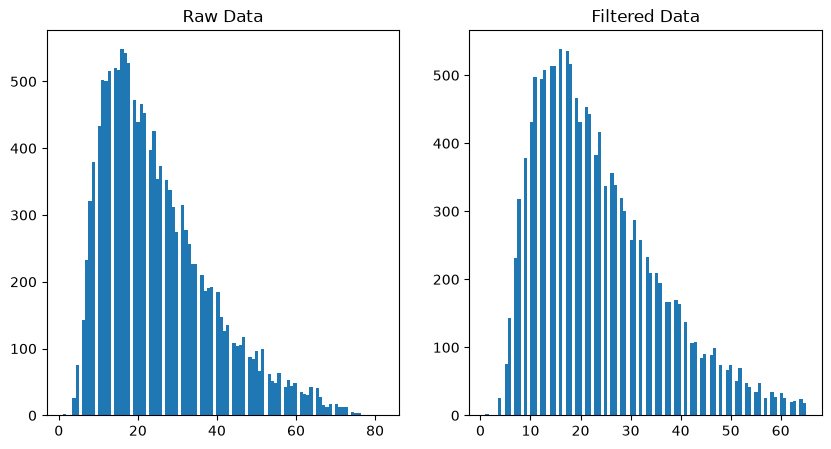

Raw Data:
95th percentile: 52.0
99th percentile: 65.0
Max: 82
Mean: 25.01663159323875

Filtered Data:
95th percentile: 48.0
99th percentile: 60.0
Max: 65
Mean: 23.581324204239202


In [5]:
import matplotlib.pyplot as plt
import numpy as np

lengths_filtered = []
for item in filtered_train:
    lengths_filtered.append(len(tokenizer.encode(item["summary"]).ids))
lengths_filtered = np.array(lengths_filtered)

lengths_raw = []
for item in train_sets:
    lengths_raw.append(len(tokenizer.encode(item["summary"]).ids))
lengths_raw.sort()
lengths_raw = np.array(lengths_raw)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(lengths_raw, bins=100)
plt.title("Raw Data")

plt.subplot(1, 2, 2)
plt.hist(lengths_filtered, bins=100)
plt.title("Filtered Data")

plt.show()

print("Raw Data:")
print("95th percentile:", np.percentile(lengths_raw, 95))
print("99th percentile:", np.percentile(lengths_raw, 99))
print("Max:", np.max(lengths_raw))
print("Mean:", np.mean(lengths_raw))
print()
print("Filtered Data:")
print("95th percentile:", np.percentile(lengths_filtered, 95))
print("99th percentile:", np.percentile(lengths_filtered, 99))
print("Max:", np.max(lengths_filtered))
print("Mean:", np.mean(lengths_filtered))

In [15]:
df_filtered_train.head()

for i in range(5):
    print(filtered_train[i]["dialogue"])
    dialogues = filtered_train[i]["dialogue"].split("\n")
    for dialogue in dialogues:
        print(dialogue.split(":"))

Amanda: I baked  cookies. Do you want some?
Jerry: Sure!
Amanda: I'll bring you tomorrow :-)
['Amanda', ' I baked  cookies. Do you want some?']
['Jerry', ' Sure!']
['Amanda', " I'll bring you tomorrow ", '-)']
Olivia: Who are you voting for in this election? 
Oliver: Liberals as always.
Olivia: Me too!!
Oliver: Great
['Olivia', ' Who are you voting for in this election? ']
['Oliver', ' Liberals as always.']
['Olivia', ' Me too!!']
['Oliver', ' Great']
Tim: Hi, what's up?
Kim: Bad mood tbh, I was going to do lots of stuff but ended up procrastinating
Tim: What did you plan on doing?
Kim: Oh you know, uni stuff and unfucking my room
Kim: Maybe tomorrow I'll move my ass and do everything
Kim: We were going to defrost a fridge so instead of shopping I'll eat some defrosted veggies
Tim: For doing stuff I recommend Pomodoro technique where u use breaks for doing chores
Tim: It really helps
Kim: thanks, maybe I'll do that
Tim: I also like using post-its in kaban style
['Tim', " Hi, what's up?